# Handwritten Digit Classification using CNN (MNIST Dataset)

## Title & Introduction

Let's dive into the world of deep learning with the MNIST dataset! This is basically the "Hello World" of computer vision. We're going to build a Convolutional Neural Network (CNN) that can recognize handwritten digits (0-9). The dataset has 70,000 images, which gives us plenty of data to train a really solid model.



## Imports & Setup

First things first, we need to bring in our tools. We'll use **NumPy** for all the math, **Matplotlib** and **Seaborn** to show off our results, and **TensorFlow/Keras** for the actual deep learning heavy lifting. I'll also set up an output directory for our plots so we can keep things organized.



In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.metrics import confusion_matrix, classification_report

# Resolve pathing for both Local and Colab environments
if os.path.exists('notebooks') or os.path.basename(os.getcwd()) == 'notebooks':
    OUTPUT_DIR = '../outputs' if os.path.basename(os.getcwd()) == 'notebooks' else 'outputs'
else:
    OUTPUT_DIR = 'outputs'

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# Setting visualization style
sns.set_theme(style="whitegrid")

## Dataset Loading

Keras makes it super easy to get the MNIST data. We'll split it into training and testing sets right away.



In [2]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(f"Dataset loaded: {x_train.shape[0]} train images, {x_test.shape[0]} test images")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Dataset loaded: 60000 train images, 10000 test images


## Data Preprocessing

Normalization and reshaping are critical steps for CNNs.



In [3]:
# Normalize and Reshape
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

## CNN Model Design

We use a Sequential model with two Convolutional layers and MaxPooling to capture hierarchical patterns.



In [4]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Compile & Train



In [5]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9608 - loss: 0.1281 - val_accuracy: 0.9819 - val_loss: 0.0557
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9871 - loss: 0.0415 - val_accuracy: 0.9836 - val_loss: 0.0507
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9913 - loss: 0.0282 - val_accuracy: 0.9886 - val_loss: 0.0330
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9937 - loss: 0.0198 - val_accuracy: 0.9914 - val_loss: 0.0265
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9951 - loss: 0.0152 - val_accuracy: 0.9891 - val_loss: 0.0388


## Advanced Evaluation

Now, let's create something worthy of a report! We'll plot both **Accuracy** and **Loss** to show the model's convergence.



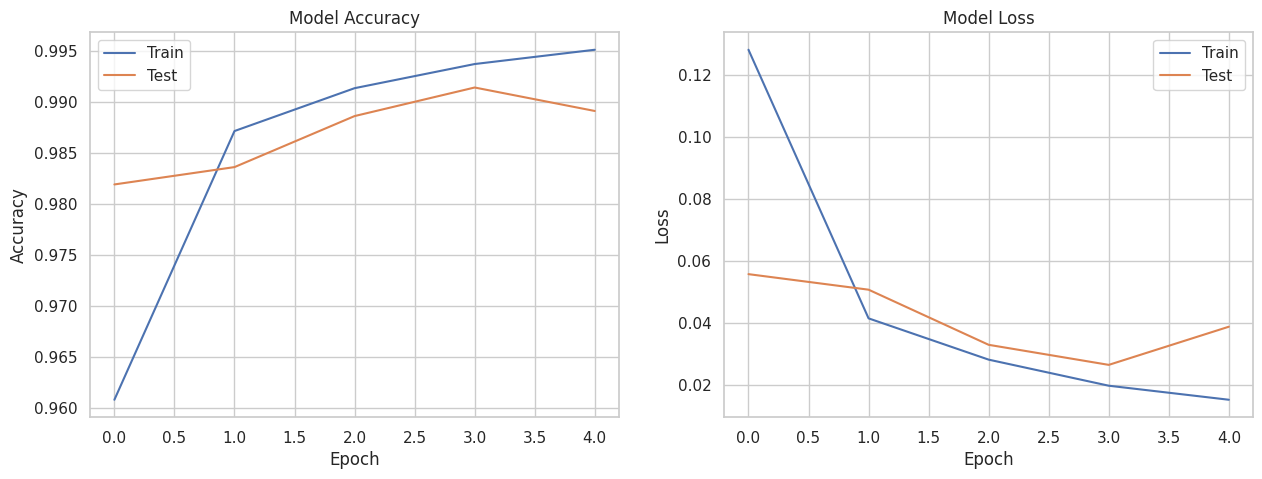

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy Plot
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Test')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Loss Plot
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Test')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.savefig(os.path.join(OUTPUT_DIR, 'learning_curves.png'), dpi=300)
plt.show()

## Confusion Matrix Analysis

A confusion matrix helps us see where the model is struggling. It's a hallmark of a strong analytical report.



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


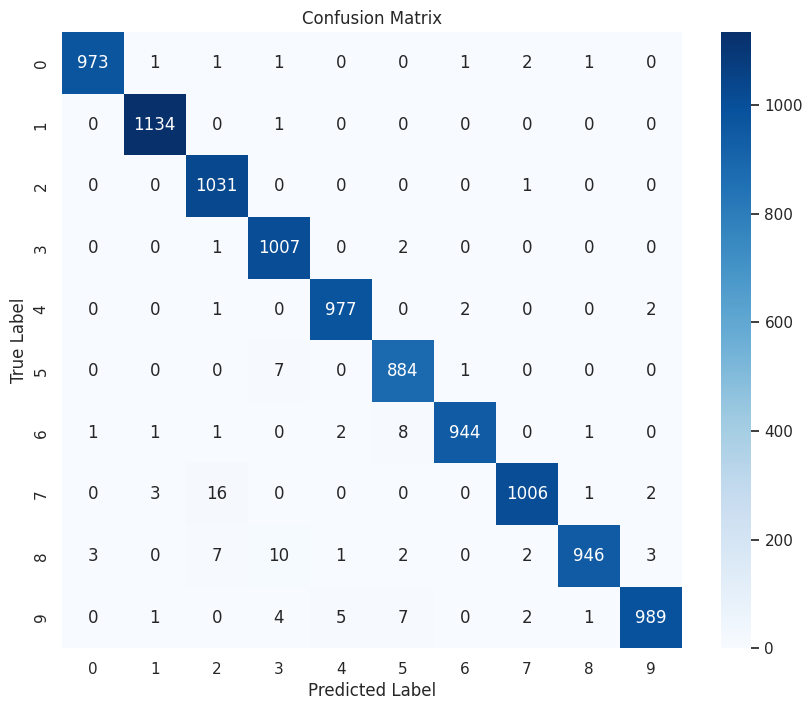


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.97      1.00      0.99      1032
           3       0.98      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.98       892
           6       1.00      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       1.00      0.97      0.98       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [7]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=300)
plt.show()

print("\nClassification Report:\n", classification_report(y_test, y_pred_classes))

## Visual Prediction Grid

Let's see the actual images and what the model thinks. Green labels are correct predictions!



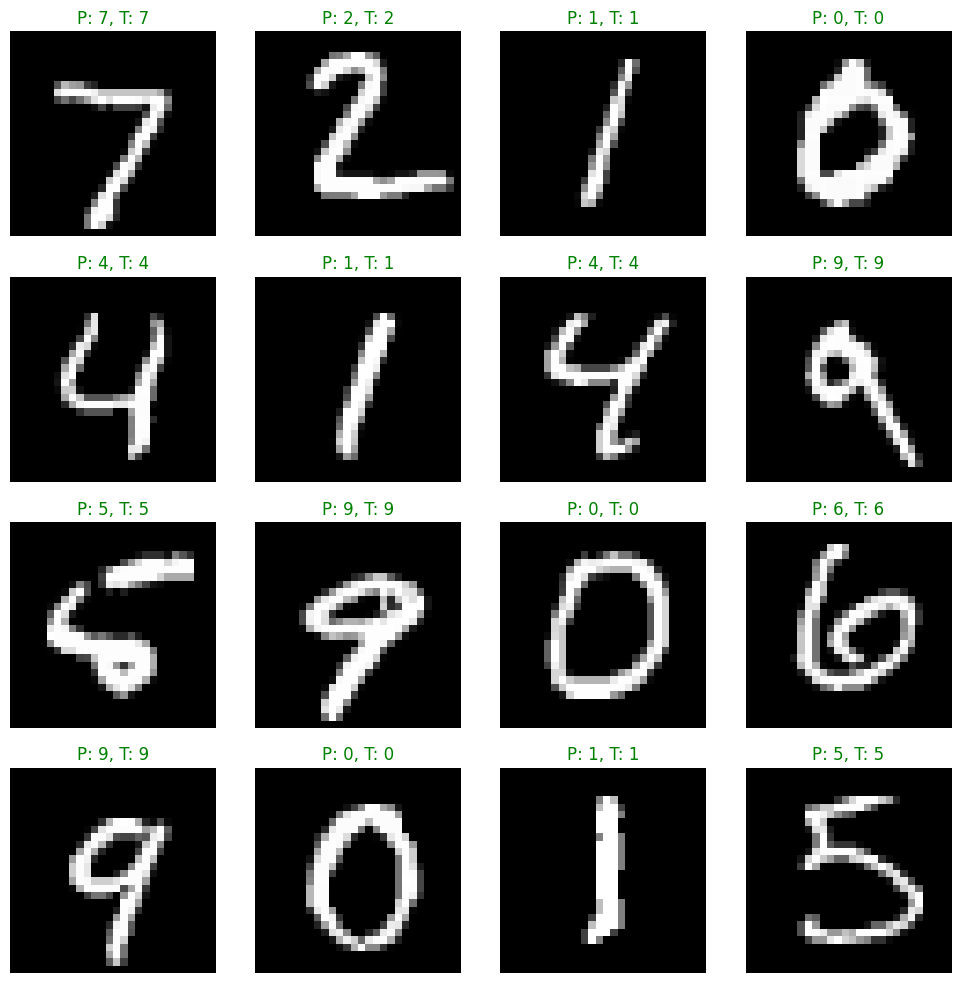

In [8]:
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    color = 'green' if y_pred_classes[i] == y_test[i] else 'red'
    plt.title(f"P: {y_pred_classes[i]}, T: {y_test[i]}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'prediction_grid.png'), dpi=300)
plt.show()

## Final Conclusion

